![alt text](image.png)

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set(style="ticks", context="notebook", palette="deep")
pd.set_option('display.max_columns', None)

In [3]:
path = "../../data/raw/"
dfs = {}

# read all dataframes and keep them in dfs
for parquet in os.listdir(path):  # List all files in the directory
    if parquet.endswith(".parquet"):
        name = parquet.split(".parquet")[0]  # Get name without extension
        dfs[name] = pd.read_parquet(os.path.join(path, parquet))  # Use os.path.join for paths
        print(f"Loaded {name} with shape {dfs[name].shape}")

Loaded 01_DiatomInventories_GTstudentproject_B with shape (1643872, 8)
Loaded 02_InfoSites_GTstudentproject_B with shape (8404, 11)
Loaded 03_IBD_GTstudentproject_test with shape (5063, 2)
Loaded 03_IBD_GTstudentproject_train with shape (43783, 4)
Loaded 04_PressureStatus_GTstudentproject_B with shape (49231, 30)
Loaded 05_EnvParamMeans_GTstudentproject_B with shape (3763903, 8)
Loaded 06_ListEnvParam_GNNprojectGT_B with shape (192, 14)
Loaded 07_TaxaCode_GTstudentproject_B with shape (2292, 2)


In [4]:
df1 = dfs[list(dfs.keys())[0]] 

se nota con el numero de unicos que el primary key para voltear es SamplingOperations_code  

In [5]:
df1.nunique()

TaxonName                            2292
TaxonCode                            2292
SamplingOperations_code             49231
CodeSite_SamplingOperations          8404
Date_SamplingOperation               2237
Abundance_nbcell                      408
TotalAbundance_SamplingOperation      188
Abundance_pm                        16667
dtype: int64

a ver mi teoria loca es que el ibd es calculado solo con taxones así:

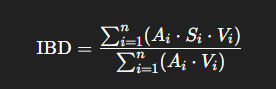

y que gracias a el super completo y coomprensivo eda de Heri se puede pensar así 

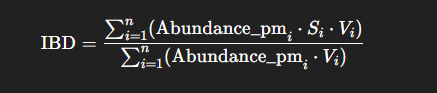


y que la regresión nos dará los valores de los demas 

In [8]:
# 1) columnas que QUIERES mantener en la llave (todas menos: TaxonName y Abundance_nbcell;
#    y quitamos TaxonCode/Abundance_pm porque se usan para columnas/valores)
cols_key = [c for c in df1.columns 
            if c not in ['TaxonName', 'Abundance_nbcell', 'TaxonCode', 'Abundance_pm']]

# 2) tabla pivote:
#    - index = todas las columnas que quieres conservar (parte del key)
#    - columns = códigos de taxón
#    - values = Abundance_pm
#    - aggfunc='sum' por si hay duplicados del mismo taxón en la misma muestra
#    - fill_value=0 para que falte → 0
wide = (
    df1.pivot_table(index=cols_key,
                   columns='TaxonCode',
                   values='Abundance_pm',
                   aggfunc='sum',
                   fill_value=0)
      .reset_index()
)

# opcional: quitar el nombre del eje de columnas
wide.columns.name = None


Ya tenemos una tabal ancha de todos los taxones y ahora los casaremos con los ibds de train

In [9]:
train =  dfs[list(dfs.keys())[3]]

NOTAR: en train solo hay como 43,000 datos y en todal de samples hay 49,000 por eso hice inner 

In [12]:
taxones = pd.merge(wide, train, on='SamplingOperations_code',how = 'inner')

Esta ya trae los datos de train y como variabels todos los taxones 

este ya es para la primera regresión que se sugiere

In [17]:
sites = dfs[list(dfs.keys())[1]]

Ahora hay otras 2 cosas que le podemos sumar por sample que son los registros unicos que son el df de pressure(también 49,000)

In [10]:
pressure = dfs[list(dfs.keys())[4]]

In [14]:
taxones_pressure = pd.merge(taxones, pressure, on='SamplingOperations_code',how = 'inner')

Tambien le voy a poner la info de sitio para tener la regiones podemo nosotros pensar que existe una constante de ibd_referencia de cada regionentonces no debemos hacer otra regresión si no dividir por la constante que corresponde a la regio si eso es a las que son 106 o22 depende de como vayamos viendo. Pero aun asi tenemos que poder casar la muestra cone so y esto esta en info sites. 

In [ ]:
#unirlo al df de solo taxones y al de taxones pressure
taxones = pd.merge(taxones, sites, on = 'CodeSite_SamplingOperations', how= 'left')
taxones_pressure = pd.merge(taxones_pressure, sites, on = 'CodeSite_SamplingOperations', how= 'left')

La ultima de environmetal aprameter means en una cosa rara 

In [22]:
epm = dfs[list(dfs.keys())[5]]
len(epm)

3763903

Hay como varios paramtros y esttos pertencen a presiones y pueden estar asciados a una muestra la muestra puede tener varios parametros. la cosa aca es que por parametro tengo la media por 3 peridos de tiempo pero esto lit no se puede interpretar porque cada parametro se lee o interprta diferente y por eso tenemos la lista en el df 6 de los que tenemos. Si no tenemos suficiente con los otros dos df vlteo este y solo nos guiamos con la otra tabla si requerimos interpretacion. 

Also, tenemos los otros 6,000 datos podemos calcularlos litlit  y esa es al clasificacioon porqur tenemos sus cosdigos de sitio y sus taxcones solo no el ibd y demas 